## 1. Perkenalan Dataset

### 1.1 Sumber Dataset

Dataset **Heart Failure Prediction** diperoleh dari Kaggle, dikurasi oleh [fedesoriano](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction). Dataset ini merupakan **gabungan dari 5 dataset jantung** yang berasal dari:
- Cleveland Heart Disease Database
- Hungarian Institute of Cardiology
- VA Long Beach Medical Center
- Swiss University Hospitals (Zurich & Basel)

Total: **918 observasi, 12 fitur**.

### 1.2 Tujuan Penggunaan Dataset

Dataset ini digunakan untuk:
1. **Membangun model klasifikasi biner** — memprediksi apakah seorang pasien mengidap penyakit jantung (1) atau tidak (0).
2. **Mempraktikkan pipeline ML end-to-end**: EDA → Preprocessing → Modeling → Monitoring.
3. **Memenuhi seluruh kriteria submission SMSML Dicoding** (Kriteria 1–4).

### 1.3 Deskripsi Fitur

| Fitur | Tipe | Deskripsi |
|---|---|---|
| Age | Numerik | Usia pasien (tahun) |
| Sex | Kategorikal | Jenis kelamin (M=Male, F=Female) |
| ChestPainType | Kategorikal | Tipe nyeri dada (TA, ATA, NAP, ASY) |
| RestingBP | Numerik | Tekanan darah saat istirahat (mmHg) |
| Cholesterol | Numerik | Kolesterol serum (mg/dl) |
| FastingBS | Biner | Gula darah puasa > 120 mg/dl (1=Ya, 0=Tidak) |
| RestingECG | Kategorikal | Hasil ECG saat istirahat (Normal, ST, LVH) |
| MaxHR | Numerik | Denyut jantung maksimal |
| ExerciseAngina | Kategorikal | Angina akibat olahraga (Y=Ya, N=Tidak) |
| Oldpeak | Numerik | Depresi ST (exercise vs rest) |
| ST_Slope | Kategorikal | Slope segmen ST (Up, Flat, Down) |

### 1.4 Deskripsi Target

| Kolom | Nilai | Makna |
|---|---|---|
| HeartDisease | 0 | Tidak memiliki penyakit jantung |
| HeartDisease | 1 | Memiliki penyakit jantung |

### 1.5 Jenis Machine Learning

**Supervised Learning — Binary Classification**

Model yang akan digunakan:
- Logistic Regression (baseline)
- Decision Tree (baseline)
- Random Forest (utama)
- Gradient Boosting (utama + tuning)

### 1.6 Alasan Memilih Dataset

1. **Mix fitur sempurna**: 6 numerik + 5 kategorikal → semua teknik preprocessing dapat didemonstrasikan
2. **Missing value natural**: kolesterol = 0 perlu ditangani
3. **Relevansi domain**: masalah kesehatan nyata, mudah diinterpretasikan reviewer
4. **Performa model tinggi**: akurasi >85% dapat dicapai → mendukung nilai ADVANCE
5. **Ukuran ideal**: 918 baris — cukup untuk semua split, tidak terlalu besar untuk CI/CD

## 2. Import Library

In [1]:
# ── Data Manipulation ─────────────────────────────────────
import pandas as pd          # Manipulasi dataframe
import numpy as np           # Operasi numerik

# ── Visualisasi ───────────────────────────────────────────
import matplotlib.pyplot as plt   # Plot dasar
import seaborn as sns             # Plot statistik tingkat lanjut
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# ── Statistik ─────────────────────────────────────────────
from scipy import stats           # Uji statistik, Z-score

# ── Preprocessing ─────────────────────────────────────────
from sklearn.preprocessing import (
    LabelEncoder,        # Encoding kategorikal biner
    StandardScaler,      # Feature scaling (zero mean, unit variance)
    MinMaxScaler,        # Scaling ke range [0,1]
    RobustScaler,        # Scaling robust terhadap outlier
)
from sklearn.model_selection import train_test_split  # Split data
from sklearn.feature_selection import mutual_info_classif  # Feature selection

# ── Utilities ─────────────────────────────────────────────
import warnings
import logging
import os
from pathlib import Path

warnings.filterwarnings('ignore')

logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s | %(levelname)s | %(message)s')
logger = logging.getLogger(__name__)

# ── Reproducibility ───────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('✓ Semua library berhasil diimport')
print(f'  pandas  : {pd.__version__}')
print(f'  numpy   : {np.__version__}')
print(f'  sklearn : {__import__("sklearn").__version__}')

✓ Semua library berhasil diimport
  pandas  : 2.3.3
  numpy   : 2.4.1
  sklearn : 1.9.0


## 3. Memuat Dataset

In [2]:
# ── Load dataset ──────────────────────────────────────────
# Pastikan file heart.csv ada di folder dataset_raw/
# Download dari: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction

DATA_PATH = '../dataset_raw/heart.csv'

df = pd.read_csv(DATA_PATH)

print('Dataset berhasil dimuat!')
print(f'Shape: {df.shape} ({df.shape[0]} baris, {df.shape[1]} kolom)')

Dataset berhasil dimuat!
Shape: (918, 12) (918 baris, 12 kolom)


In [3]:
# 5 data pertama
print('=== 5 Data Pertama ===')
df.head()

=== 5 Data Pertama ===


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
# Informasi dataset
print('=== Informasi Dataset ===')
df.info()

=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
# Tipe data
print('=== Tipe Data ===')
print(df.dtypes)

print('\n=== Jumlah Missing Values ===')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0] if missing.sum() > 0 else 'Tidak ada missing value')

print('\n=== Jumlah Duplikat ===')
dup = df.duplicated().sum()
print(f'{dup} baris duplikat ({dup/len(df)*100:.2f}%)')

=== Tipe Data ===
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

=== Jumlah Missing Values ===
Tidak ada missing value

=== Jumlah Duplikat ===
0 baris duplikat (0.00%)


## 4. Exploratory Data Analysis (EDA)

### 4.1 Analisis Struktur Data

In [6]:
# Identifikasi kolom numerik dan kategorikal
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# Hapus target dari fitur
feature_num = [c for c in num_cols if c != 'HeartDisease']
feature_cat = cat_cols.copy()

print(f'Fitur Numerik  ({len(feature_num)}): {feature_num}')
print(f'Fitur Kategorikal ({len(feature_cat)}): {feature_cat}')
print(f'Target: HeartDisease')

# Value counts setiap kolom kategorikal
for col in feature_cat:
    print(f'\n--- {col} ---')
    print(df[col].value_counts())

Fitur Numerik  (6): ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
Fitur Kategorikal (5): ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
Target: HeartDisease

--- Sex ---
Sex
M    725
F    193
Name: count, dtype: int64

--- ChestPainType ---
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

--- RestingECG ---
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

--- ExerciseAngina ---
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

--- ST_Slope ---
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64


### 4.2 Statistik Deskriptif

In [7]:
# Statistik lengkap fitur numerik
desc = df[feature_num + ['HeartDisease']].describe().T
desc['median'] = df[feature_num + ['HeartDisease']].median()
desc['mode']   = df[feature_num + ['HeartDisease']].mode().iloc[0]
desc['cv%']    = (desc['std'] / desc['mean'] * 100).round(2)

print('=== Statistik Deskriptif Lengkap ===')
desc[['count','mean','median','mode','std','min','25%','50%','75%','max','cv%']]

=== Statistik Deskriptif Lengkap ===


,count,mean,median,mode,std,min,25%,50%,75%,max,cv%
Age,918.0,53.510893,54.0,54.0,9.432617,28.0,47.00,54.0,60.0,77.0,17.63
RestingBP,918.0,132.396514,130.0,120.0,18.514154,0.0,120.00,130.0,140.0,200.0,13.98
Cholesterol,918.0,198.799564,223.0,0.0,109.384145,0.0,173.25,223.0,267.0,603.0,55.02
FastingBS,918.0,0.233115,0.0,0.0,0.423046,0.0,0.00,0.0,0.0,1.0,181.47
MaxHR,918.0,136.809368,138.0,150.0,25.460334,60.0,120.00,138.0,156.0,202.0,18.61
Oldpeak,918.0,0.887364,0.6,0.0,1.066570,-2.6,0.00,0.6,1.5,6.2,120.20
HeartDisease,918.0,0.553377,1.0,1.0,0.497414,0.0,0.00,1.0,1.0,1.0,89.89


**Insight Statistik Deskriptif:**
- `Cholesterol`: nilai minimum = 0 → tidak mungkin secara medis. Ini merupakan *missing value* yang dikodekan sebagai 0. Perlu imputasi.
- `RestingBP`: ada nilai 0 → kemungkinan data entry error. Perlu ditangani.
- `Oldpeak`: memiliki nilai negatif — valid secara medis (elevasi ST).
- `Age` dan `MaxHR` memiliki distribusi yang relatif normal.

### 4.3 Analisis Univariate

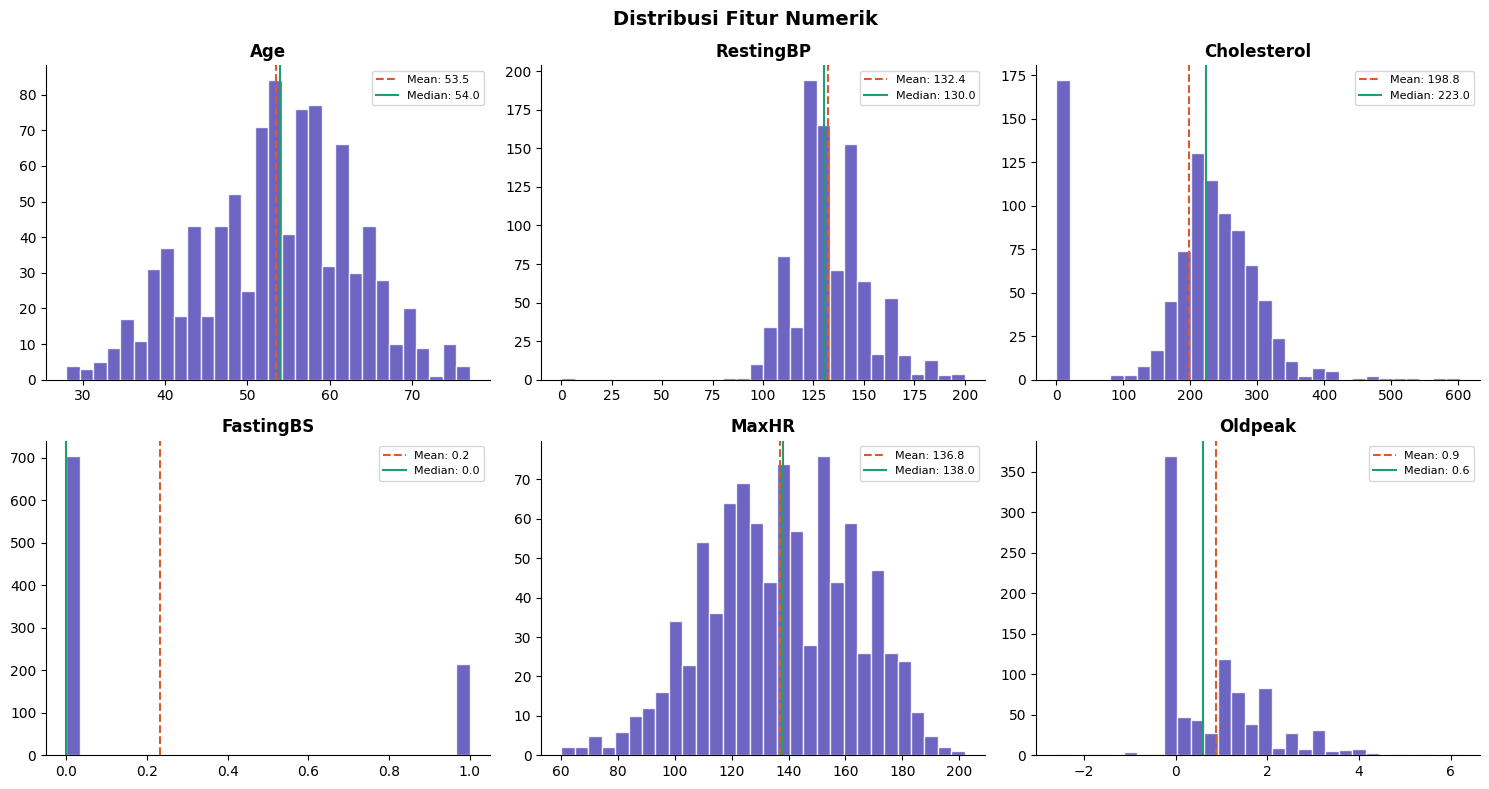

Insight: Cholesterol memiliki spike pada nilai 0 — perlu imputasi.


In [8]:
# Distribusi fitur numerik
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(feature_num):
    axes[i].hist(df[col], bins=30, color='#534AB7', edgecolor='white', alpha=0.85)
    axes[i].axvline(df[col].mean(),   color='#D85A30', ls='--', lw=1.5, label=f'Mean: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='#1D9E75', ls='-',  lw=1.5, label=f'Median: {df[col].median():.1f}')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribusi Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../preprocessing/eda_output/01_num_distributions.png', dpi=120, bbox_inches='tight')
plt.show()
print('Insight: Cholesterol memiliki spike pada nilai 0 — perlu imputasi.')

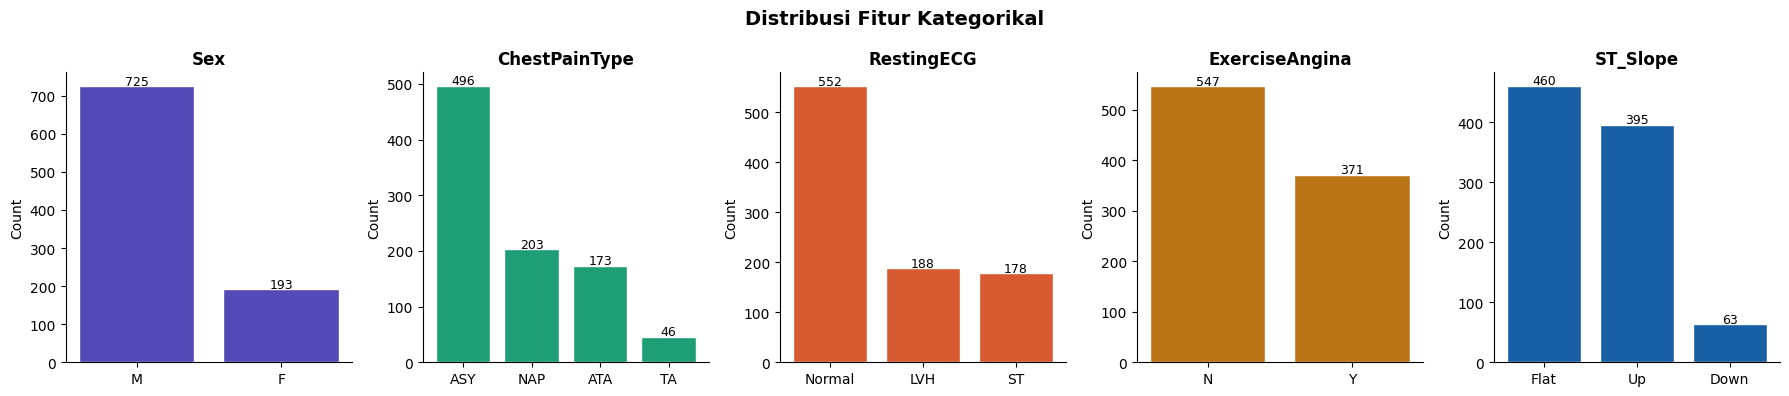

In [9]:
# Distribusi fitur kategorikal
fig, axes = plt.subplots(1, len(feature_cat), figsize=(18, 4))

colors = ['#534AB7','#1D9E75','#D85A30','#BA7517','#185FA5']
for i, col in enumerate(feature_cat):
    vc = df[col].value_counts()
    axes[i].bar(vc.index, vc.values, color=colors[i % len(colors)], edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Count')
    for bar, val in zip(axes[i].patches, vc.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                     str(val), ha='center', fontsize=9)

plt.suptitle('Distribusi Fitur Kategorikal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../preprocessing/eda_output/02_cat_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

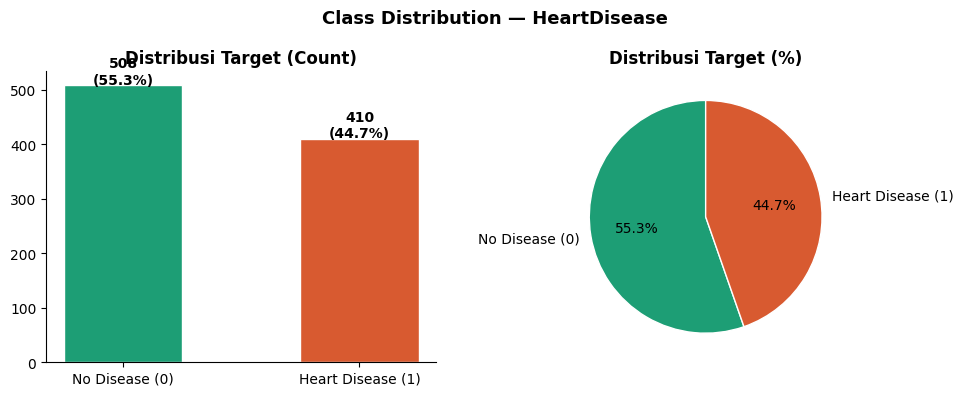

Kelas 0 (No Disease) : 410 (44.7%)
Kelas 1 (Heart Dis.) : 508 (55.3%)
Class ratio          : 0.81:1

Insight: Distribusi relatif seimbang (~45:55), stratified split sudah cukup.


In [10]:
# Distribusi target
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

vc = df['HeartDisease'].value_counts()
labels = ['No Disease (0)', 'Heart Disease (1)']

ax1.bar(labels, vc.values, color=['#1D9E75','#D85A30'], edgecolor='white', width=0.5)
for bar, val in zip(ax1.patches, vc.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontweight='bold')
ax1.set_title('Distribusi Target (Count)', fontweight='bold')

ax2.pie(vc.values, labels=labels, colors=['#1D9E75','#D85A30'],
        autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor':'white'})
ax2.set_title('Distribusi Target (%)', fontweight='bold')

plt.suptitle('Class Distribution — HeartDisease', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../preprocessing/eda_output/03_target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Kelas 0 (No Disease) : {vc[0]} ({vc[0]/len(df)*100:.1f}%)')
print(f'Kelas 1 (Heart Dis.) : {vc[1]} ({vc[1]/len(df)*100:.1f}%)')
print(f'Class ratio          : {vc[0]/vc[1]:.2f}:1')
print('\nInsight: Distribusi relatif seimbang (~45:55), stratified split sudah cukup.')

### 4.4 Analisis Bivariate

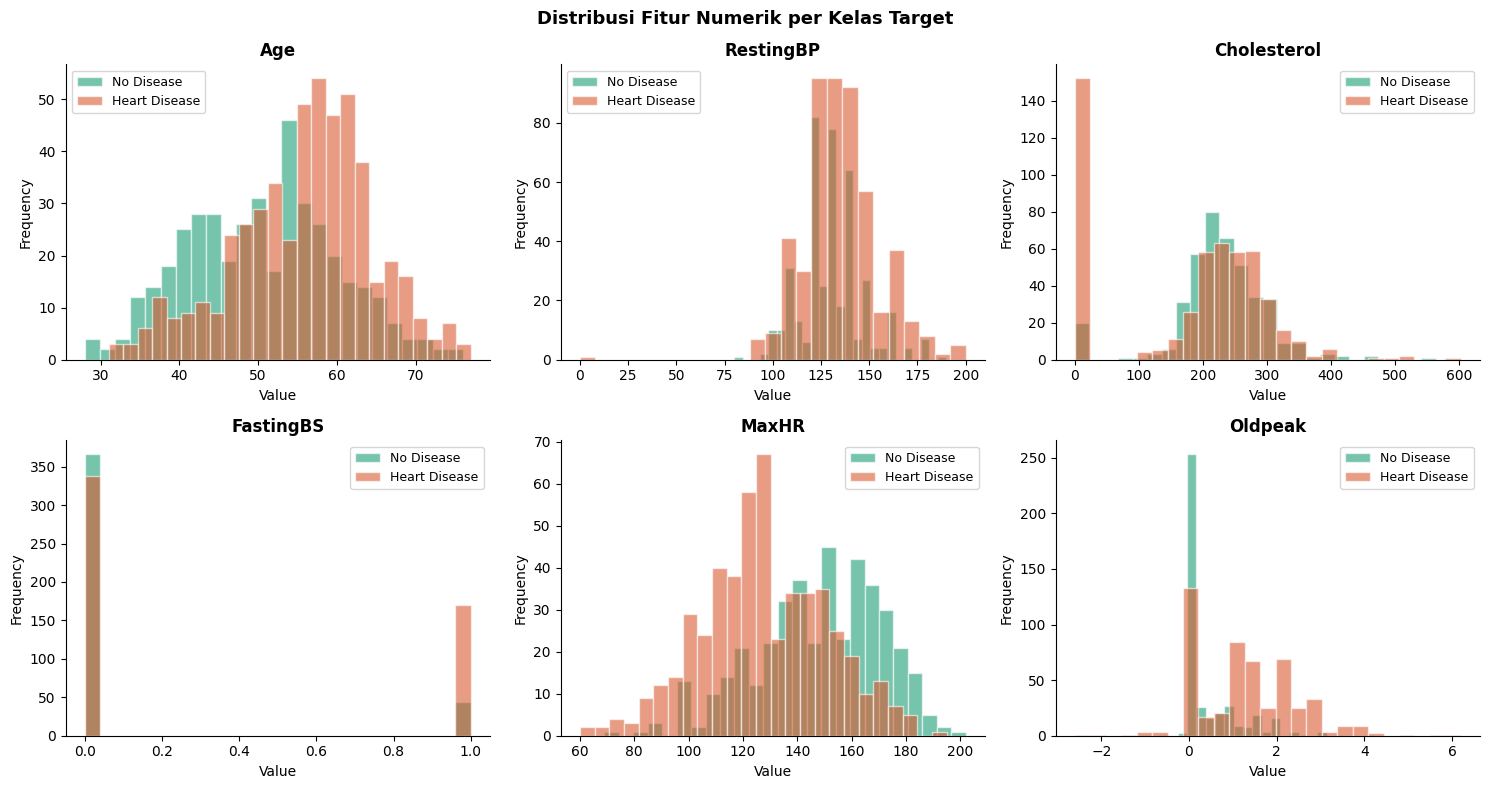

In [11]:
# Distribusi fitur numerik per kelas target
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(feature_num):
    for tval, color, label in [(0,'#1D9E75','No Disease'),(1,'#D85A30','Heart Disease')]:
        axes[i].hist(df[df['HeartDisease']==tval][col],
                     bins=25, alpha=0.6, color=color, label=label, edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=9)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Distribusi Fitur Numerik per Kelas Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../preprocessing/eda_output/04_bivariate_num_target.png', dpi=120, bbox_inches='tight')
plt.show()

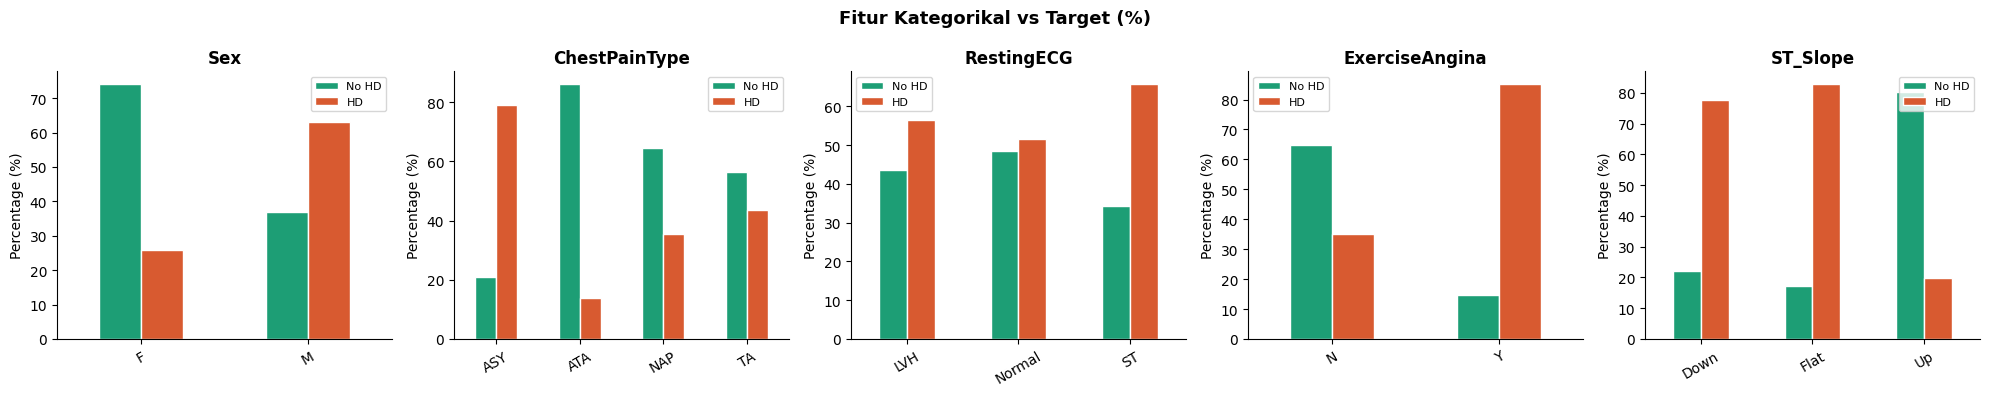

In [12]:
# Fitur kategorikal vs target (stacked bar)
fig, axes = plt.subplots(1, len(feature_cat), figsize=(20, 4))

for i, col in enumerate(feature_cat):
    ct = pd.crosstab(df[col], df['HeartDisease'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['#1D9E75','#D85A30'],
            edgecolor='white', stacked=False)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend(['No HD','HD'], fontsize=8)
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Fitur Kategorikal vs Target (%)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../preprocessing/eda_output/05_cat_vs_target.png', dpi=120, bbox_inches='tight')
plt.show()

### 4.5 Analisis Multivariate

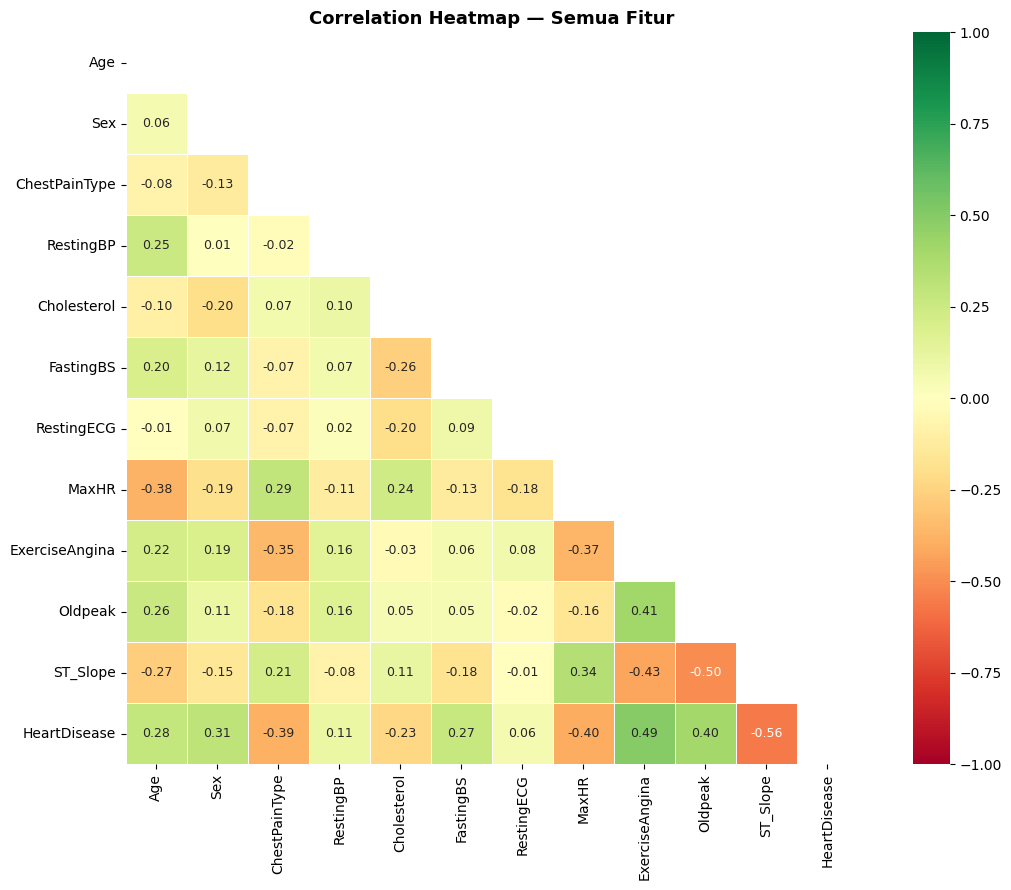


=== Korelasi Absolut dengan Target ===
ST_Slope          0.559
ExerciseAngina    0.494
Oldpeak           0.404
MaxHR             0.400
ChestPainType     0.387
Sex               0.305
Age               0.282
FastingBS         0.267
Cholesterol       0.233
RestingBP         0.108
RestingECG        0.057

Insight: ST_Slope dan ExerciseAngina memiliki korelasi tertinggi dengan HeartDisease.


In [13]:
# Encode semua kolom untuk heatmap
df_enc = df.copy()
le = LabelEncoder()
for col in feature_cat:
    df_enc[col] = le.fit_transform(df_enc[col])

corr = df_enc.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=0.5, annot_kws={'size': 9},
            square=True)
ax.set_title('Correlation Heatmap — Semua Fitur', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../preprocessing/eda_output/06_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

# Korelasi tertinggi dengan target
target_corr = corr['HeartDisease'].drop('HeartDisease').abs().sort_values(ascending=False)
print('\n=== Korelasi Absolut dengan Target ===')
print(target_corr.round(3).to_string())
print('\nInsight: ST_Slope dan ExerciseAngina memiliki korelasi tertinggi dengan HeartDisease.')

### 4.6 Outlier Analysis

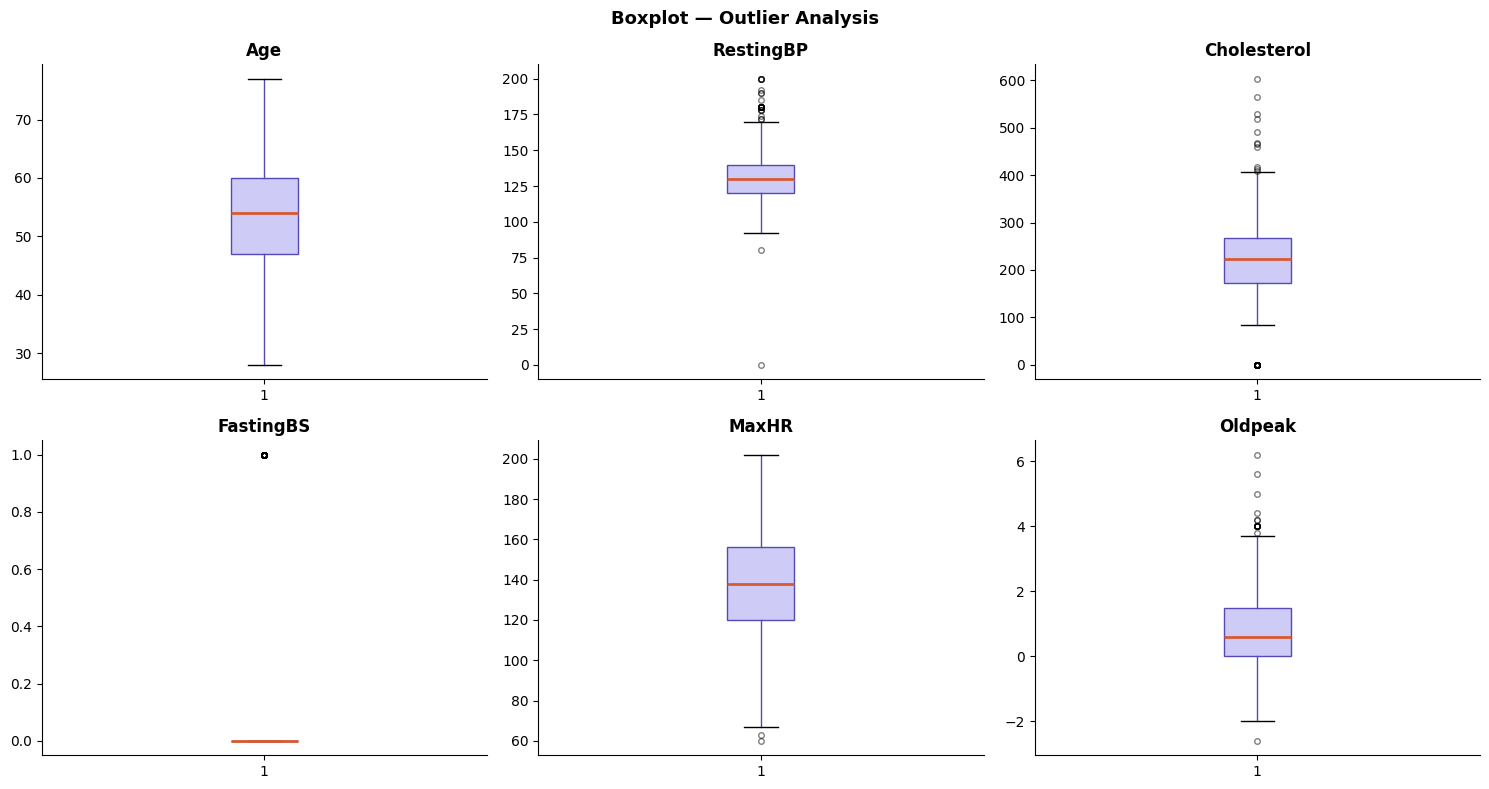

In [14]:
# Boxplot semua fitur numerik
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(feature_num):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#CECBF6', color='#534AB7'),
                    medianprops=dict(color='#D85A30', linewidth=2),
                    whiskerprops=dict(color='#534AB7'),
                    flierprops=dict(marker='o', color='#D85A30', alpha=0.5, markersize=4))
    axes[i].set_title(col, fontweight='bold')

plt.suptitle('Boxplot — Outlier Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../preprocessing/eda_output/07_boxplots.png', dpi=120, bbox_inches='tight')
plt.show()

In [15]:
# IQR Analysis — hitung jumlah outlier per fitur
print('=== IQR Outlier Analysis ===')
print(f'{"Fitur":<20} {"Q1":>8} {"Q3":>8} {"IQR":>8} {"Lower":>10} {"Upper":>10} {"#Outliers":>10} {"% Outliers":>12}')
print('-' * 90)

for col in feature_num:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 1.5 * IQR
    hi  = Q3 + 1.5 * IQR
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    pct   = n_out / len(df) * 100
    print(f'{col:<20} {Q1:>8.2f} {Q3:>8.2f} {IQR:>8.2f} {lo:>10.2f} {hi:>10.2f} {n_out:>10} {pct:>11.1f}%')

print('\nInsight: Cholesterol memiliki outlier paling banyak — nilai 0 adalah pseudo-outlier.')

=== IQR Outlier Analysis ===
Fitur                      Q1       Q3      IQR      Lower      Upper  #Outliers   % Outliers
------------------------------------------------------------------------------------------
Age                     47.00    60.00    13.00      27.50      79.50          0         0.0%
RestingBP              120.00   140.00    20.00      90.00     170.00         28         3.1%
Cholesterol            173.25   267.00    93.75      32.62     407.62        183        19.9%
FastingBS                0.00     0.00     0.00       0.00       0.00        214        23.3%
MaxHR                  120.00   156.00    36.00      66.00     210.00          2         0.2%
Oldpeak                  0.00     1.50     1.50      -2.25       3.75         16         1.7%

Insight: Cholesterol memiliki outlier paling banyak — nilai 0 adalah pseudo-outlier.


## 5. Data Preprocessing

### 5.1 Handling Missing Values

In [16]:
df_clean = df.copy()

# Cholesterol = 0 adalah nilai tidak valid secara medis → ganti dengan NaN dulu
n_chol_zero = (df_clean['Cholesterol'] == 0).sum()
print(f'Kolesterol = 0 ditemukan: {n_chol_zero} baris ({n_chol_zero/len(df_clean)*100:.1f}%)')
df_clean.loc[df_clean['Cholesterol'] == 0, 'Cholesterol'] = np.nan

# RestingBP = 0 juga tidak valid
n_bp_zero = (df_clean['RestingBP'] == 0).sum()
print(f'RestingBP = 0 ditemukan : {n_bp_zero} baris')
df_clean.loc[df_clean['RestingBP'] == 0, 'RestingBP'] = np.nan

print(f'\nMissing sebelum imputasi: {df_clean.isnull().sum().sum()}')

# Imputasi median (lebih robust terhadap outlier vs mean)
for col in feature_num:
    n_nan = df_clean[col].isnull().sum()
    if n_nan > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f'  {col}: imputasi {n_nan} NaN dengan median = {median_val:.2f}')

print(f'Missing setelah imputasi: {df_clean.isnull().sum().sum()}')
print('\nAlasan: Median dipilih karena distribusi Cholesterol tidak normal dan ada outlier.')

Kolesterol = 0 ditemukan: 172 baris (18.7%)
RestingBP = 0 ditemukan : 1 baris

Missing sebelum imputasi: 173
  RestingBP: imputasi 1 NaN dengan median = 130.00
  Cholesterol: imputasi 172 NaN dengan median = 237.00
Missing setelah imputasi: 0

Alasan: Median dipilih karena distribusi Cholesterol tidak normal dan ada outlier.


### 5.2 Handling Duplicates

In [17]:
n_dup = df_clean.duplicated().sum()
print(f'Duplikat ditemukan: {n_dup}')

if n_dup > 0:
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)
    print(f'Duplikat dihapus. Shape baru: {df_clean.shape}')
else:
    print('Tidak ada duplikat — tidak ada aksi.')
    print(f'Shape tetap: {df_clean.shape}')

Duplikat ditemukan: 0
Tidak ada duplikat — tidak ada aksi.
Shape tetap: (918, 12)


### 5.3 Handling Outliers

In [18]:
# Metode: IQR Capping (Winsorization)
# Alasan: Lebih aman dari zscore karena tidak membuang data;
#         cocok untuk dataset kecil (918 baris)

cols_to_cap = [c for c in feature_num if c != 'HeartDisease']

print('=== Outlier Capping dengan IQR (factor=1.5) ===')
for col in cols_to_cap:
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 1.5 * IQR
    hi  = Q3 + 1.5 * IQR
    n_out = ((df_clean[col] < lo) | (df_clean[col] > hi)).sum()
    df_clean[col] = df_clean[col].clip(lower=lo, upper=hi)
    print(f'  {col:<20}: {n_out} outlier di-cap ke [{lo:.2f}, {hi:.2f}]')

print(f'\nShape setelah outlier handling: {df_clean.shape}')

=== Outlier Capping dengan IQR (factor=1.5) ===
  Age                 : 0 outlier di-cap ke [27.50, 79.50]
  RestingBP           : 27 outlier di-cap ke [90.00, 170.00]
  Cholesterol         : 41 outlier di-cap ke [134.50, 346.50]
  FastingBS           : 214 outlier di-cap ke [0.00, 0.00]
  MaxHR               : 2 outlier di-cap ke [66.00, 210.00]
  Oldpeak             : 16 outlier di-cap ke [-2.25, 3.75]

Shape setelah outlier handling: (918, 12)


### 5.4 Encoding Fitur Kategorikal

In [19]:
# Label Encoding → fitur dengan 2 nilai unik
# One-Hot Encoding → fitur dengan >2 nilai unik

le = LabelEncoder()
ohe_cols   = []
label_cols = []

for col in feature_cat:
    n_unique = df_clean[col].nunique()
    if n_unique == 2:
        df_clean[col] = le.fit_transform(df_clean[col])
        label_cols.append(col)
        print(f'Label Encoded: {col} → {dict(zip(le.classes_, le.transform(le.classes_)))}')
    else:
        ohe_cols.append(col)
        print(f'OneHot Queued: {col} ({n_unique} kategori)')

if ohe_cols:
    df_clean = pd.get_dummies(df_clean, columns=ohe_cols, drop_first=False, dtype=int)
    print(f'\nSetelah OHE — kolom baru: {[c for c in df_clean.columns if any(o in c for o in ohe_cols)]}')

print(f'\nShape setelah encoding: {df_clean.shape}')
print(f'Kolom: {list(df_clean.columns)}')

Label Encoded: Sex → {'F': np.int64(0), 'M': np.int64(1)}
OneHot Queued: ChestPainType (4 kategori)
OneHot Queued: RestingECG (3 kategori)
Label Encoded: ExerciseAngina → {'N': np.int64(0), 'Y': np.int64(1)}
OneHot Queued: ST_Slope (3 kategori)

Setelah OHE — kolom baru: ['ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']

Shape setelah encoding: (918, 19)
Kolom: ['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'HeartDisease', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']


### 5.5 Feature Selection

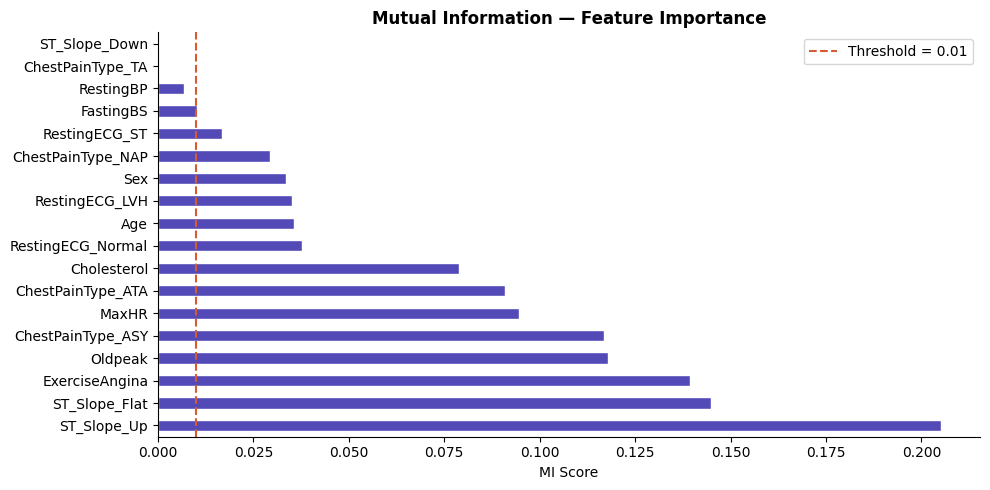


Fitur dipilih (15): ['ST_Slope_Up', 'ST_Slope_Flat', 'ExerciseAngina', 'Oldpeak', 'ChestPainType_ASY', 'MaxHR', 'ChestPainType_ATA', 'Cholesterol', 'RestingECG_Normal', 'Age', 'RestingECG_LVH', 'Sex', 'ChestPainType_NAP', 'RestingECG_ST', 'FastingBS']
Fitur dibuang (3): ['RestingBP', 'ChestPainType_TA', 'ST_Slope_Down']
Shape setelah feature selection: (918, 16)


In [20]:
X_temp = df_clean.drop(columns=['HeartDisease'])
y_temp = df_clean['HeartDisease']

mi_scores = mutual_info_classif(X_temp, y_temp, random_state=RANDOM_STATE)
mi_series = pd.Series(mi_scores, index=X_temp.columns).sort_values(ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
mi_series.plot(kind='barh', ax=ax, color='#534AB7', edgecolor='white')
ax.axvline(x=0.01, color='#D85A30', ls='--', label='Threshold = 0.01')
ax.set_title('Mutual Information — Feature Importance', fontweight='bold')
ax.set_xlabel('MI Score')
ax.legend()
plt.tight_layout()
plt.savefig('../preprocessing/eda_output/08_mutual_information.png', dpi=120, bbox_inches='tight')
plt.show()

THRESHOLD = 0.01
selected_features = mi_series[mi_series >= THRESHOLD].index.tolist()
dropped_features  = mi_series[mi_series < THRESHOLD].index.tolist()

print(f'\nFitur dipilih ({len(selected_features)}): {selected_features}')
print(f'Fitur dibuang ({len(dropped_features)}): {dropped_features}')

df_selected = df_clean[selected_features + ['HeartDisease']]
print(f'Shape setelah feature selection: {df_selected.shape}')

### 5.6 Feature Scaling

In [21]:
# StandardScaler dipilih karena:
# 1. Banyak model ML (SVM, Logistic Regression) sensitif terhadap skala
# 2. Dataset sudah di-outlier-cap sehingga aman menggunakan StandardScaler
# 3. Mempertahankan distribusi data

X = df_selected.drop(columns=['HeartDisease'])
y = df_selected['HeartDisease']

num_to_scale = X.select_dtypes(include=['float64','int64']).columns.tolist()
# Jangan scale kolom binary (0/1)
binary_cols  = [c for c in num_to_scale if X[c].nunique() == 2]
scale_cols   = [c for c in num_to_scale if X[c].nunique() > 2]

scaler = StandardScaler()
X[scale_cols] = scaler.fit_transform(X[scale_cols])

print(f'Kolom yang di-scale ({len(scale_cols)}): {scale_cols}')
print(f'Kolom binary (tidak di-scale): {binary_cols}')
print(f'\nSetelah scaling:')
print(X[scale_cols].describe().T[['mean','std','min','max']].round(3))

Kolom yang di-scale (4): ['Oldpeak', 'MaxHR', 'Cholesterol', 'Age']
Kolom binary (tidak di-scale): ['ST_Slope_Up', 'ST_Slope_Flat', 'ExerciseAngina', 'ChestPainType_ASY', 'ChestPainType_ATA', 'RestingECG_Normal', 'RestingECG_LVH', 'Sex', 'ChestPainType_NAP', 'RestingECG_ST']

Setelah scaling:
             mean    std    min    max
Oldpeak       0.0  1.001 -3.033  2.786
MaxHR        -0.0  1.001 -2.786  2.564
Cholesterol  -0.0  1.001 -2.369  2.337
Age          -0.0  1.001 -2.706  2.492


### 5.7 Data Splitting

In [22]:
# Stratified split: 70% train / 10% val / 20% test
# Alasan:
# - Stratified: menjaga proporsi kelas di semua split
# - 70/10/20: standar industri, cukup data untuk training dan evaluasi

# Step 1: pisahkan test (20%)
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# Step 2: pisahkan val (10% dari total = 12.5% dari sisanya)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.125, stratify=y_tv, random_state=RANDOM_STATE
)

print('=== Hasil Data Splitting ===')
print(f'Total data  : {len(X)} ({len(X)} = 100%)')
print(f'Train set   : {len(X_train)} rows ({len(X_train)/len(X)*100:.1f}%)')
print(f'Val set     : {len(X_val)} rows ({len(X_val)/len(X)*100:.1f}%)')
print(f'Test set    : {len(X_test)} rows ({len(X_test)/len(X)*100:.1f}%)')

print('\n=== Distribusi Target per Split ===')
for name, y_split in [('Train', y_train),('Val', y_val),('Test', y_test)]:
    dist = y_split.value_counts(normalize=True).mul(100).round(1)
    print(f'{name:6s}: No HD = {dist.get(0,0)}%  |  HD = {dist.get(1,0)}%')

=== Hasil Data Splitting ===
Total data  : 918 (918 = 100%)
Train set   : 642 rows (69.9%)
Val set     : 92 rows (10.0%)
Test set    : 184 rows (20.0%)

=== Distribusi Target per Split ===
Train : No HD = 44.7%  |  HD = 55.3%
Val   : No HD = 44.6%  |  HD = 55.4%
Test  : No HD = 44.6%  |  HD = 55.4%


### 5.8 Simpan Dataset Preprocessed

In [23]:
import os
os.makedirs('../preprocessing/dataset_preprocessing', exist_ok=True)

# Gabungkan X + y sebelum disimpan
train_df = X_train.copy(); train_df['HeartDisease'] = y_train.values
val_df   = X_val.copy();   val_df['HeartDisease']   = y_val.values
test_df  = X_test.copy();  test_df['HeartDisease']  = y_test.values

train_df.to_csv('../preprocessing/dataset_preprocessing/train.csv', index=False)
val_df.to_csv('../preprocessing/dataset_preprocessing/val.csv',     index=False)
test_df.to_csv('../preprocessing/dataset_preprocessing/test.csv',   index=False)

print('=== Dataset Preprocessed Berhasil Disimpan ===')
print(f'  train.csv : {train_df.shape}')
print(f'  val.csv   : {val_df.shape}')
print(f'  test.csv  : {test_df.shape}')
print(f'  Kolom     : {list(train_df.columns)}')

=== Dataset Preprocessed Berhasil Disimpan ===
  train.csv : (642, 16)
  val.csv   : (92, 16)
  test.csv  : (184, 16)
  Kolom     : ['ST_Slope_Up', 'ST_Slope_Flat', 'ExerciseAngina', 'Oldpeak', 'ChestPainType_ASY', 'MaxHR', 'ChestPainType_ATA', 'Cholesterol', 'RestingECG_Normal', 'Age', 'RestingECG_LVH', 'Sex', 'ChestPainType_NAP', 'RestingECG_ST', 'FastingBS', 'HeartDisease']


## 6. Ringkasan Preprocessing

In [24]:
print('╔══════════════════════════════════════════════════════╗')
print('║       RINGKASAN PREPROCESSING PIPELINE              ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Dataset awal      : {df.shape[0]} baris, {df.shape[1]} kolom              ║')
print(f'║  Dataset akhir     : {len(X)} baris, {X.shape[1]} fitur              ║')
print('║                                                      ║')
print('║  Langkah yang dilakukan:                             ║')
print('║  ✓ 1. Handle missing values  (median imputation)    ║')
print('║  ✓ 2. Remove duplicates                             ║')
print('║  ✓ 3. Handle outliers        (IQR capping)          ║')
print('║  ✓ 4. Encoding               (LabelEnc + OHE)       ║')
print('║  ✓ 5. Feature selection      (Mutual Information)   ║')
print('║  ✓ 6. Feature scaling        (StandardScaler)       ║')
print('║  ✓ 7. Data splitting         (70/10/20 stratified)  ║')
print('║  ✓ 8. Save preprocessed CSVs                        ║')
print('║                                                      ║')
print(f'║  Train: {len(X_train):4d} | Val: {len(X_val):3d} | Test: {len(X_test):3d}                ║')
print('╚══════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════╗
║       RINGKASAN PREPROCESSING PIPELINE              ║
╠══════════════════════════════════════════════════════╣
║  Dataset awal      : 918 baris, 12 kolom              ║
║  Dataset akhir     : 918 baris, 15 fitur              ║
║                                                      ║
║  Langkah yang dilakukan:                             ║
║  ✓ 1. Handle missing values  (median imputation)    ║
║  ✓ 2. Remove duplicates                             ║
║  ✓ 3. Handle outliers        (IQR capping)          ║
║  ✓ 4. Encoding               (LabelEnc + OHE)       ║
║  ✓ 5. Feature selection      (Mutual Information)   ║
║  ✓ 6. Feature scaling        (StandardScaler)       ║
║  ✓ 7. Data splitting         (70/10/20 stratified)  ║
║  ✓ 8. Save preprocessed CSVs                        ║
║                                                      ║
║  Train:  642 | Val:  92 | Test: 184                ║
╚═══════════════════════════════════════